In [29]:
import os 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.metrics import precision_recall_curve

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn import preprocessing

#Modèles
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyClassifier 
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [ ]:
import sys
print(sys.executable)

C:\Users\nibaj\anaconda3\envs\oc_env\python.exe


In [ ]:
!pip list

Package                            Version
---------------------------------- ------------------
aext-assistant                     4.1.0
aext-assistant-server              4.1.0
aext-core                          4.1.0
aext-core-server                   4.1.0
aext-panels                        4.1.0
aext-panels-server                 4.1.0
aext-project-filebrowser-server    4.1.0
aext-share-notebook                4.1.0
aext-share-notebook-server         4.1.0
aext-shared                        4.1.0
aext-toolbox                       4.1.0
aiobotocore                        2.12.3
aiohappyeyeballs                   2.4.0
aiohttp                            3.10.5
aioitertools                       0.7.1
aiosignal                          1.2.0
alabaster                          0.7.16
alembic                            1.13.3
altair                             5.0.1
anaconda-anon-usage                0.4.4
anaconda-catalogs                  0.2.0
anaconda-cli-base                  0.4

In [ ]:
!pip install mlflow

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.6 which is incompatible.


In [ ]:
!python -V

Python 3.12.7


In [ ]:
mlflow.set_experiment("MLflow Quickstart")

In [ ]:
mettre a jour numpy avant 

In [ ]:
os.getcwd()

'C:\\Users\\nibaj\\Openclassrooms\\Projet 6'

Colonnes bonne à fusinner : SK id Curr, 
Pas de doublons 
Catégories pertinentes : Contract type , amt total income, amt anuity , nb d'enfants 
Plusieurs type de colonnes 

In [31]:
app_train = pd.read_csv("application_train.csv")
app_train.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
app_test = pd.read_csv("application_test.csv")
app_test.head(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
bureau = pd.read_csv("bureau.csv")
bureau.head(5)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [36]:
bb = pd.read_csv("bureau_balance.csv")
bb.head(5)

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [38]:
cc = pd.read_csv("credit_card_balance.csv")
cc.head(5)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [39]:
pos_cash = pd.read_csv("POS_CASH_balance.csv")
pos_cash.head(5)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [40]:
homecredit = pd.read_csv("HomeCredit_columns_description.csv",encoding="latin-1")
homecredit.head(5)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [41]:
installments = pd.read_csv("installments_payments.csv")
installments.head(5)

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [232]:
log = pd.read_csv("log_reg_baseline.csv")
log.head(5)

,SK_ID_CURR
0,100001
1,100005
2,100013
3,100028
4,100038


In [43]:
previous_app = pd.read_csv("previous_application.csv")
previous_app.head(5)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
sample = pd.read_csv("sample_submission.csv")
sample.head(5)

,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5
3,100028,0.5
4,100038,0.5


In [ ]:
ANALYSE EXPLORATOIRE

In [236]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [239]:
missing_values = missing_values_table(app_train)
missing_values.head(10)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


In [240]:
app_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


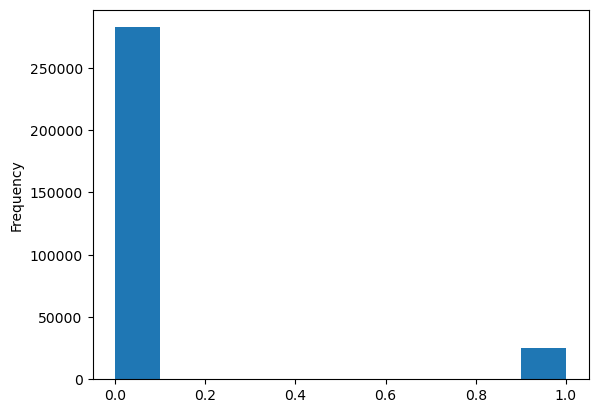

In [69]:
app_train['TARGET'].astype(int).plot.hist();

In [55]:
app_train.dtypes.value_counts()

float64    65
int64      40
object     16
Name: count, dtype: int64

In [57]:
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               7
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             5
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [71]:
missing_values = missing_values_table(app_test)
missing_values.head(10)

Your selected dataframe has 121 columns.
There are 64 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MODE,33495,68.7
COMMONAREA_MEDI,33495,68.7
COMMONAREA_AVG,33495,68.7
NONLIVINGAPARTMENTS_MEDI,33347,68.4
NONLIVINGAPARTMENTS_AVG,33347,68.4
NONLIVINGAPARTMENTS_MODE,33347,68.4
FONDKAPREMONT_MODE,32797,67.3
LIVINGAPARTMENTS_MODE,32780,67.2
LIVINGAPARTMENTS_MEDI,32780,67.2
LIVINGAPARTMENTS_AVG,32780,67.2


In [73]:
app_test.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               7
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             5
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

In [75]:
missing_values = missing_values_table(bureau)
missing_values.head(10)

Your selected dataframe has 17 columns.
There are 7 columns that have missing values.


,Missing Values,% of Total Values
AMT_ANNUITY,1226791,71.5
AMT_CREDIT_MAX_OVERDUE,1124488,65.5
DAYS_ENDDATE_FACT,633653,36.9
AMT_CREDIT_SUM_LIMIT,591780,34.5
AMT_CREDIT_SUM_DEBT,257669,15.0
DAYS_CREDIT_ENDDATE,105553,6.1
AMT_CREDIT_SUM,13,0.0


In [ ]:
bureau.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

In [ ]:
missing_values = missing_values_table(pos_cash)
missing_values.head(10)

In [ ]:
pos_cash.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

In [ ]:
missing_values = missing_values_table(bureau_balance)
missing_values.head(10)

In [40]:
bb.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

STATUS    8
dtype: int64

In [42]:
missing_values = missing_values_table(previous_app)
missing_values.head(20)

Your selected dataframe has 37 columns.
There are 16 columns that have missing values.


,Missing Values,% of Total Values
RATE_INTEREST_PRIMARY,1664263,99.6
RATE_INTEREST_PRIVILEGED,1664263,99.6
AMT_DOWN_PAYMENT,895844,53.6
RATE_DOWN_PAYMENT,895844,53.6
NAME_TYPE_SUITE,820405,49.1
DAYS_FIRST_DRAWING,673065,40.3
DAYS_FIRST_DUE,673065,40.3
DAYS_LAST_DUE_1ST_VERSION,673065,40.3
DAYS_LAST_DUE,673065,40.3
DAYS_TERMINATION,673065,40.3


In [44]:
previous_app.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE              4
WEEKDAY_APPR_PROCESS_START      7
FLAG_LAST_APPL_PER_CONTRACT     2
NAME_CASH_LOAN_PURPOSE         25
NAME_CONTRACT_STATUS            4
NAME_PAYMENT_TYPE               4
CODE_REJECT_REASON              9
NAME_TYPE_SUITE                 7
NAME_CLIENT_TYPE                4
NAME_GOODS_CATEGORY            28
NAME_PORTFOLIO                  5
NAME_PRODUCT_TYPE               3
CHANNEL_TYPE                    8
NAME_SELLER_INDUSTRY           11
NAME_YIELD_GROUP                5
PRODUCT_COMBINATION            17
dtype: int64

In [81]:
missing_values = missing_values_table(log)
missing_values.head(20)

Your selected dataframe has 1 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [54]:
log.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

Series([], dtype: float64)

In [56]:
missing_values = missing_values_table(sample)
missing_values.head(10)

Your selected dataframe has 2 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [57]:
sample.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

Series([], dtype: float64)

In [60]:
missing_values = missing_values_table(cc_balance)
missing_values.head(20)

Your selected dataframe has 23 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
AMT_PAYMENT_CURRENT,767988,20.0
AMT_DRAWINGS_ATM_CURRENT,749816,19.5
AMT_DRAWINGS_OTHER_CURRENT,749816,19.5
AMT_DRAWINGS_POS_CURRENT,749816,19.5
CNT_DRAWINGS_ATM_CURRENT,749816,19.5
CNT_DRAWINGS_OTHER_CURRENT,749816,19.5
CNT_DRAWINGS_POS_CURRENT,749816,19.5
AMT_INST_MIN_REGULARITY,305236,7.9
CNT_INSTALMENT_MATURE_CUM,305236,7.9


In [61]:
cc_balance.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_STATUS    7
dtype: int64

In [62]:
missing_values = missing_values_table(installments)
missing_values.head(10)

Your selected dataframe has 8 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
DAYS_ENTRY_PAYMENT,2905,0.0
AMT_PAYMENT,2905,0.0


In [64]:
installments.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

Series([], dtype: float64)

In [65]:
missing_values = missing_values_table(homecredit)
missing_values.head(10)

Your selected dataframe has 5 columns.
There are 1 columns that have missing values.


,Missing Values,% of Total Values
Special,133,60.7


In [71]:
homecredit.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

Table            7
Row            196
Description    163
Special          7
dtype: int64

In [ ]:
missing_values = missing_values_table(bureau)
missing_values.head(20)

Your selected dataframe has 17 columns.
There are 7 columns that have missing values.


,Missing Values,% of Total Values
AMT_ANNUITY,1226791,71.5
AMT_CREDIT_MAX_OVERDUE,1124488,65.5
DAYS_ENDDATE_FACT,633653,36.9
AMT_CREDIT_SUM_LIMIT,591780,34.5
AMT_CREDIT_SUM_DEBT,257669,15.0
DAYS_CREDIT_ENDDATE,105553,6.1
AMT_CREDIT_SUM,13,0.0


In [79]:
bureau.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

CREDIT_ACTIVE       4
CREDIT_CURRENCY     4
CREDIT_TYPE        15
dtype: int64

Encodage des variables
LE : cc_balance, pos_cash, bureau_balance
OHE : bureau , app_test, previous_app,

In [48]:
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [49]:
def label_encode_binary(df):
    le = LabelEncoder()
    count = 0
    
    for col in df.columns:
        if df[col].dtype == 'object':
            if df[col].nunique() <= 2:
                df[col] = le.fit_transform(df[col])
                count += 1
                
    print(f"{count} colonnes encodées dans ce dataframe.")
    return df

In [50]:
cc.select_dtypes('object').columns
pos_cash.select_dtypes('object').columns
bb.select_dtypes('object').columns

Index(['STATUS'], dtype='object')

In [51]:
cc = label_encode_binary(cc)

0 colonnes encodées dans ce dataframe.


In [52]:
pos_cash = label_encode_binary(pos_cash)

0 colonnes encodées dans ce dataframe.


In [75]:
bb = label_encode_binary(bb)

0 colonnes encodées dans ce dataframe.


In [77]:
# one-hot encoding of categorical variables
app_train_encode = pd.get_dummies(app_train)
app_test_encode = pd.get_dummies(app_test)
bureau_encode = pd.get_dummies(bureau)
previous_app_encode = pd.get_dummies(previous_app)
pos_cash_encode = pd.get_dummies(pos_cash)
bb_encode =pd.get_dummies(bb)
cc_encode =pd.get_dummies(cc)




print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 122)
Testing Features shape:  (48744, 121)


In [ ]:
pos_cash_encode

In [ ]:
AGGREGATION DES DATA SET 

In [143]:
train = app_train.copy()
test = app_test.copy()

In [145]:
for df in [train, test]:
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

    df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365
    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
    df["CREDIT_TERM"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

    df["EXT_SOURCE_MEAN"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)

In [109]:

bb_agg = bb_encode.groupby("SK_ID_BUREAU").agg({
    "MONTHS_BALANCE": ["min", "max", "size"],
    "STATUS_0": "mean",
    "STATUS_1": "mean",
    "STATUS_2": "mean",
    "STATUS_3": "mean",
    "STATUS_4": "mean",
    "STATUS_5": "mean",
    "STATUS_C": "mean",
    "STATUS_X": "mean"
})

bb_agg.columns = ["BB_" + "_".join(col) for col in bb_agg.columns]
bb_agg = bb_agg.reset_index()

bb_agg = bb_agg.merge(
    bureau[["SK_ID_BUREAU", "SK_ID_CURR"]],
    on="SK_ID_BUREAU",
    how="left"
)

bb_agg = bb_agg.drop(columns="SK_ID_BUREAU").groupby("SK_ID_CURR").mean().reset_index()

In [110]:
bb_agg

,SK_ID_CURR,BB_MONTHS_BALANCE_min,BB_MONTHS_BALANCE_max,BB_MONTHS_BALANCE_size,BB_STATUS_0_mean,BB_STATUS_1_mean,BB_STATUS_2_mean,BB_STATUS_3_mean,BB_STATUS_4_mean,BB_STATUS_5_mean,BB_STATUS_C_mean,BB_STATUS_X_mean
0,100001.0,-23.571429,0.000000,24.571429,0.336651,0.007519,0.0,0.0,0.0,0.0,0.441240,0.214590
1,100002.0,-28.250000,-15.500000,13.750000,0.406960,0.255682,0.0,0.0,0.0,0.0,0.175426,0.161932
2,100005.0,-6.000000,0.000000,7.000000,0.735043,0.000000,0.0,0.0,0.0,0.0,0.128205,0.136752
3,100010.0,-63.500000,-28.500000,36.000000,0.277778,0.000000,0.0,0.0,0.0,0.0,0.722222,0.000000
4,100013.0,-56.500000,0.000000,57.500000,0.320718,0.027701,0.0,0.0,0.0,0.0,0.397036,0.254545
...,...,...,...,...,...,...,...,...,...,...,...,...
134537,456247.0,-33.909091,-5.818182,29.090909,0.325528,0.000000,0.0,0.0,0.0,0.0,0.505634,0.168838
134538,456250.0,-28.000000,0.000000,29.000000,0.130259,0.000000,0.0,0.0,0.0,0.0,0.252525,0.617216
134539,456253.0,-28.250000,0.000000,29.250000,0.404906,0.000000,0.0,0.0,0.0,0.0,0.459677,0.135417
134540,456254.0,-36.000000,0.000000,37.000000,0.216216,0.000000,0.0,0.0,0.0,0.0,0.783784,0.000000


In [113]:
bureau_agg = bureau_encode.groupby("SK_ID_CURR").agg({
    "SK_ID_BUREAU": "count",
    "DAYS_CREDIT": ["mean", "min", "max"],
    "CREDIT_DAY_OVERDUE": ["mean", "max"],
    "AMT_CREDIT_SUM": ["mean", "sum", "max"],
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],
    "AMT_CREDIT_SUM_OVERDUE": ["mean", "sum"],
    "AMT_ANNUITY": ["mean", "sum"]
})

bureau_agg.columns = ["BUREAU_" + "_".join(col) for col in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()

In [115]:
bureau_cat_cols = [
    col for col in bureau_encode.columns
    if col.startswith("CREDIT_ACTIVE_")
    or col.startswith("CREDIT_CURRENCY_")
    or col.startswith("CREDIT_TYPE_")
]

bureau_cat_agg = bureau_encode.groupby("SK_ID_CURR")[bureau_cat_cols].mean().reset_index()

bureau_agg = bureau_agg.merge(
    bureau_cat_agg,
    on="SK_ID_CURR",
    how="left"
)

Supprimer des colonnes avec presque 100%  de valeurs manquantes
previous_app_simple = previous_app.drop(
    columns=["RATE_INTEREST_PRIVILEGED", "RATE_INTEREST_PRIMARY"],
    errors="ignore"
)

Création de quelques features simple 

In [117]:
previous_app["APP_CREDIT_RATIO"] = (
    previous_app["AMT_APPLICATION"] / previous_app["AMT_CREDIT"]
)

previous_app["APPROVED"] = (
    previous_app["NAME_CONTRACT_STATUS"] == "Approved"
).astype(int)

previous_app["REFUSED"] = (
    previous_app["NAME_CONTRACT_STATUS"] == "Refused"
).astype(int)

In [119]:
previous_agg = previous_app.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "count",
    "AMT_ANNUITY": ["mean", "max"],
    "AMT_APPLICATION": ["mean", "max", "sum"],
    "AMT_CREDIT": ["mean", "max", "sum"],
    "AMT_DOWN_PAYMENT": ["mean", "max"],
    "AMT_GOODS_PRICE": ["mean", "max"],
    "DAYS_DECISION": ["mean", "min", "max"],
    "CNT_PAYMENT": ["mean", "sum"],
    "APP_CREDIT_RATIO": ["mean", "max"],
    "APPROVED": ["mean", "sum"],
    "REFUSED": ["mean", "sum"]
})

previous_agg.columns = ["PREV_" + "_".join(col) for col in previous_agg.columns]
previous_agg = previous_agg.reset_index()

In [121]:
installments["PAYMENT_DELAY"] = (
    installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
)

installments["PAYMENT_RATIO"] = (
    installments["AMT_PAYMENT"] / installments["AMT_INSTALMENT"]
)

installments_agg = installments.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "nunique",
    "NUM_INSTALMENT_NUMBER": ["mean", "max"],
    "DAYS_INSTALMENT": ["mean", "min", "max"],
    "DAYS_ENTRY_PAYMENT": ["mean", "min", "max"],
    "AMT_INSTALMENT": ["mean", "sum", "max"],
    "AMT_PAYMENT": ["mean", "sum", "max"],
    "PAYMENT_DELAY": ["mean", "max"],
    "PAYMENT_RATIO": ["mean", "min"]
})

installments_agg.columns = ["INS_" + "_".join(col) for col in installments_agg.columns]
installments_agg = installments_agg.reset_index()

In [122]:

cc["LIMIT_USE"] = cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"]
cc["LATE_PAYMENT"] = (cc["SK_DPD"] > 0).astype(int)

cc_agg = cc.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "nunique",
    "MONTHS_BALANCE": ["min", "max", "size"],
    "AMT_BALANCE": ["mean", "max", "sum"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean", "max"],
    "AMT_DRAWINGS_CURRENT": ["mean", "max", "sum"],
    "AMT_PAYMENT_CURRENT": ["mean", "max", "sum"],
    "SK_DPD": ["mean", "max", "sum"],
    "SK_DPD_DEF": ["mean", "max", "sum"],
    "LIMIT_USE": ["mean", "max"],
    "LATE_PAYMENT": ["mean", "sum"]
})

cc_agg.columns = ["CC_" + "_".join(col) for col in cc_agg.columns]
cc_agg = cc_agg.reset_index()

In [123]:
pos_cash["POS_LATE_PAYMENT"] = (pos_cash["SK_DPD"] > 0).astype(int)

pos_cash["REMAINING_RATIO"] = (
    pos_cash["CNT_INSTALMENT_FUTURE"] / pos_cash["CNT_INSTALMENT"]
)

pos_agg = pos_cash.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "nunique",
    "MONTHS_BALANCE": ["min", "max", "size"],
    "CNT_INSTALMENT": ["mean", "max"],
    "CNT_INSTALMENT_FUTURE": ["mean", "min", "max"],
    "SK_DPD": ["mean", "max", "sum"],
    "SK_DPD_DEF": ["mean", "max", "sum"],
    "POS_LATE_PAYMENT": ["mean", "sum"],
    "REMAINING_RATIO": ["mean", "min"]
})

pos_agg.columns = ["POS_" + "_".join(col) for col in pos_agg.columns]
pos_agg = pos_agg.reset_index()

MERGE AVEC TRAIN ET TEST 

In [147]:
tables_to_merge = [
    bb_agg,
    bureau_agg,
    previous_agg,
    installments_agg,
    cc_agg,
    pos_agg
]

for table in tables_to_merge:
    train = train.merge(table, on="SK_ID_CURR", how="left")
    test = test.merge(table, on="SK_ID_CURR", how="left")

In [ ]:
Vérifier le nombre de lignes 

In [148]:
print(app_train.shape[0], train.shape[0])
print(app_test.shape[0], test.shape[0])

307511 307511
48744 48744


In [ ]:
assert app_train.shape[0] == train.shape[0]
assert app_test.shape[0] == test.shape[0]

Preparation des features 
X = DATA - TARGET
y = "Target

In [151]:
target = train["TARGET"]

train_no_target = train.drop(columns=["TARGET"])
combined = pd.concat([train_no_target, test], axis=0)

combined = pd.get_dummies(combined, dummy_na=True)

train_final = combined.iloc[:len(train_no_target), :].copy()
test_final = combined.iloc[len(train_no_target):, :].copy()

train_final["TARGET"] = target.values

In [152]:
X = train_final.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y = train_final["TARGET"]

X_test = test_final.drop(columns=["SK_ID_CURR"], errors="ignore")

Les jeux de données 

In [153]:
train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,POS_SK_DPD_mean,POS_SK_DPD_max,POS_SK_DPD_sum,POS_SK_DPD_DEF_mean,POS_SK_DPD_DEF_max,POS_SK_DPD_DEF_sum,POS_POS_LATE_PAYMENT_mean,POS_POS_LATE_PAYMENT_sum,POS_REMAINING_RATIO_mean,POS_REMAINING_RATIO_min
0,100002,1,0,M,0,1,0,202500.0,406597.5,24700.5,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.625000,0.250000
1,100003,0,0,F,0,0,0,270000.0,1293502.5,35698.5,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.544643,0.000000
2,100004,0,1,M,1,1,0,67500.0,135000.0,6750.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.562500,0.000000
3,100006,0,0,F,0,1,0,135000.0,312682.5,29686.5,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.570833,0.000000
4,100007,0,0,M,0,1,0,121500.0,513000.0,21865.5,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.557561,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,0,M,0,0,0,157500.0,254700.0,27558.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.546875,0.000000
307507,456252,0,0,F,0,1,0,72000.0,269550.0,12001.5,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.500000,0.000000
307508,456253,0,0,F,0,1,0,153000.0,677664.0,29979.0,...,0.294118,5.0,5.0,0.294118,5.0,5.0,0.058824,1.0,0.367647,0.000000
307509,456254,1,0,F,0,1,0,171000.0,370107.0,20205.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.691071,0.285714


In [296]:
test

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,POS_SK_DPD_mean,POS_SK_DPD_max,POS_SK_DPD_sum,POS_SK_DPD_DEF_mean,POS_SK_DPD_DEF_max,POS_SK_DPD_DEF_sum,POS_POS_LATE_PAYMENT_mean,POS_POS_LATE_PAYMENT_sum,POS_REMAINING_RATIO_mean,POS_REMAINING_RATIO_min
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.777778,7.0,7.0,0.777778,7.0,7.0,0.111111,1.0,0.361111,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.600000,0.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0.944444,18.0,34.0,0.000000,0.0,0.0,0.055556,2.0,0.631173,0.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.491129,0.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.487179,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.718750,0.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.513514,0.0
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.555018,0.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.583065,0.0


In [161]:
import mlflow

In [163]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("credit_scoring_home_credit")

print("Tracking URI :", mlflow.get_tracking_uri())
print("Experiment :", mlflow.get_experiment_by_name("credit_scoring_home_credit"))

2026/06/17 17:11:21 INFO mlflow.tracking.fluent: Experiment with name 'credit_scoring_home_credit' does not exist. Creating a new experiment.


Tracking URI : http://127.0.0.1:5000
Experiment : <Experiment: artifact_location='mlflow-artifacts:/928879627721808344', creation_time=1781709081997, effective_trace_archival_retention=None, experiment_id='928879627721808344', last_update_time=1781709081997, lifecycle_stage='active', name='credit_scoring_home_credit', tags={}, trace_location=None, workspace='default'>


In [165]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [167]:
with mlflow.start_run(run_name="test_connexion_notebook"):
    mlflow.set_tag("projet", "credit_scoring")
    mlflow.set_tag("etape", "test_mlflow")
    
    mlflow.log_param("test_parametre", "connexion_ok")
    mlflow.log_metric("test_auc", 0.75)

🏃 View run test_connexion_notebook at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/c4ea91e33c3643f98d04dc05906ece8d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344


In [ ]:
VRAI PARAMETRES OUTILS DE SCORING

Formules log() pour renvoyer dans MLflow

In [306]:
def run_mlflow_test(model, run_name, model_type):
    
    with mlflow.start_run(run_name=run_name):
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_valid)
        y_proba = model.predict_proba(X_valid)[:, 1]
        
        roc_auc = roc_auc_score(y_valid, y_proba)
        recall = recall_score(y_valid, y_pred)
        f1 = f1_score(y_valid, y_pred)
        accuracy = accuracy_score(y_valid, y_pred)
        
        mlflow.log_param("model_type", model_type)
        mlflow.log_params(model.get_params())
        
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("accuracy", accuracy)
        
        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            registered_model_name="credit_scoring_classifier"
        )
        
        print(run_name)
        print("ROC-AUC :", roc_auc)
        print("Recall :", recall)
        print("F1-score :", f1)
        print("Accuracy :", accuracy)
        print("-" * 50)
        
        return {
            "run_name": run_name,
            "model_type": model_type,
            "roc_auc": roc_auc,
            "recall": recall,
            "f1_score": f1,
            "accuracy": accuracy,
            "model": model
        }

In [308]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

In [ ]:
Regression logistic

In [193]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [ ]:
Random Forest 

In [185]:

random_forest_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
RF avec de meilleurs paramètres

In [195]:
rf_test_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=100,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

result_4 = run_mlflow_test(
    model=rf_test_2,
    run_name="04_random_forest_regularized",
    model_type="RandomForestClassifier"
)

🏃 View run 04_random_forest_regularized at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/0f23dfa7a4ae41028f785dfc986b0409
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344


NameError: name 'X_train' is not defined

In [157]:
import numpy as np
import pandas as pd

# X / y
X = train_final.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y = train_final["TARGET"]

# Garder uniquement les colonnes numériques
X = X.select_dtypes(include=["number", "bool"])

# Remplacer les infinis créés par des divisions par zéro
X = X.replace([np.inf, -np.inf], np.nan)

# Convertir les booléens en 0/1
X = X.astype(float)

print("Shape X :", X.shape)
print("Nombre de colonnes object :", X.select_dtypes("object").shape[1])
print("Nombre de valeurs infinies :", np.isinf(X).sum().sum())
print("Nombre de NaN :", X.isna().sum().sum())

Shape X : (307511, 395)
Nombre de colonnes object : 0
Nombre de valeurs infinies : 0
Nombre de NaN : 19323456


In [300]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [302]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("credit_scoring_home_credit")


def run_mlflow_test(model, run_name, model_type):
    
    with mlflow.start_run(run_name=run_name):
        
        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("problem_type", "binary_classification")
        mlflow.set_tag("target", "TARGET")
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_valid)
        y_proba = model.predict_proba(X_valid)[:, 1]
        
        roc_auc = roc_auc_score(y_valid, y_proba)
        recall = recall_score(y_valid, y_pred)
        f1 = f1_score(y_valid, y_pred)
        accuracy = accuracy_score(y_valid, y_pred)
        
        mlflow.log_param("model_type", model_type)
        
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("accuracy", accuracy)
        
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model"
        )
        
        print("Run terminé avec succès :", run_name)
        print("ROC-AUC :", roc_auc)
        print("Recall :", recall)
        print("F1-score :", f1)
        print("Accuracy :", accuracy)
        
        return {
            "run_name": run_name,
            "model_type": model_type,
            "roc_auc": roc_auc,
            "recall": recall,
            "f1_score": f1,
            "accuracy": accuracy,
            "model": model
        }

Regression Logistic

In [205]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

result_1 = run_mlflow_test(
    model=logistic_model,
    run_name="01_logistic_regression_baseline",
    model_type="LogisticRegression"
)


2026/06/18 20:49:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/18 20:52:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/18 20:52:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run terminé avec succès : 01_logistic_regression_baseline
ROC-AUC : 0.7727459438112134
Recall : 0.7033232628398791
F1-score : 0.28091062665915856
Accuracy : 0.7093149927645805
🏃 View run 01_logistic_regression_baseline at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/85a0231810ad4009ab28f608d9fed1fa
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344


In [ ]:
Graphique pour detecter les faux negatif

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

result_2 = run_mlflow_test(
    model=rf_baseline,
    run_name="02_random_forest_baseline",
    model_type="RandomForestClassifier"
)

In [ ]:
Dummy classifier 

In [312]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

dummy_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DummyClassifier(
        strategy="most_frequent",
        random_state=42
    ))
])

result_dummy = run_mlflow_test(
    model=dummy_model,
    run_name="00_dummy_classifier_baseline",
    model_type="DummyClassifier"
)

2026/06/19 11:05:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\nibaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026/06/19 11:06:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 11:06:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Pyt

00_dummy_classifier_baseline
ROC-AUC : 0.5
Recall : 0.0
F1-score : 0.0
Accuracy : 0.9192722306228964
--------------------------------------------------
🏃 View run 00_dummy_classifier_baseline at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/1fa098e9f7ad4cb0a4fc3570ffde1137
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344


In [ ]:
Amélioration avec le grid search

In [316]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [344]:
import time
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score


def run_rf_gridsearch_light(param_grid, run_name):
    
    # Sécurité : désactiver autolog pour éviter les conflits
    mlflow.sklearn.autolog(disable=True)
    
    if mlflow.active_run() is not None:
        mlflow.end_run()
    
    rf_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(
            random_state=42,
            n_jobs=1
        ))
    ])
    
    cv = StratifiedKFold(
        n_splits=2,
        shuffle=True,
        random_state=42
    )
    
    grid_search = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=1,
        verbose=1,
        pre_dispatch=1
    )
    
    # Nom unique pour éviter les reprises de run
    unique_run_name = run_name + "_" + str(int(time.time()))
    
    with mlflow.start_run(run_name=unique_run_name):
        
        grid_search.fit(X_train_small, y_train_small)
        
        best_model = grid_search.best_estimator_
        
        y_pred = best_model.predict(X_valid_small)
        y_proba = best_model.predict_proba(X_valid_small)[:, 1]
        
        roc_auc = roc_auc_score(y_valid_small, y_proba)
        recall = recall_score(y_valid_small, y_pred)
        f1 = f1_score(y_valid_small, y_pred)
        accuracy = accuracy_score(y_valid_small, y_pred)
        
        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("problem_type", "binary_classification")
        mlflow.set_tag("model_family", "RandomForestClassifier")
        mlflow.set_tag("run_type", "GridSearchCV_light")
        
        mlflow.log_param("model_type", "RandomForestClassifier")
        mlflow.log_param("scoring", "roc_auc")
        mlflow.log_param("cv_folds", 2)
        
        mlflow.log_params(grid_search.best_params_)
        
        mlflow.log_metric("best_cv_roc_auc", grid_search.best_score_)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("accuracy", accuracy)
        
        mlflow.sklearn.log_model(
            sk_model=best_model,
            artifact_path="model"
        )
        
        print(unique_run_name)
        print("Meilleurs paramètres :", grid_search.best_params_)
        print("Best CV ROC-AUC :", grid_search.best_score_)
        print("ROC-AUC validation :", roc_auc)
        print("Recall :", recall)
        print("F1-score :", f1)
        print("Accuracy :", accuracy)
        print("-" * 60)
        
        return {
            "run_name": unique_run_name,
            "best_params": grid_search.best_params_,
            "best_cv_roc_auc": grid_search.best_score_,
            "roc_auc": roc_auc,
            "recall": recall,
            "f1_score": f1,
            "accuracy": accuracy,
            "model": best_model
        }

In [327]:
import numpy as np

X_train_small = X_train.replace([np.inf, -np.inf], np.nan).astype(np.float32)
X_valid_small = X_valid.replace([np.inf, -np.inf], np.nan).astype(np.float32)

y_train_small = y_train.copy()
y_valid_small = y_valid.copy()

print(X_train_small.shape)
print(X_train_small.dtypes.value_counts())

(246008, 401)
float32    401
Name: count, dtype: int64


autolog

In [342]:
import mlflow
import mlflow.sklearn

# Désactiver l'autologging pour éviter les conflits de paramètres
mlflow.sklearn.autolog(disable=True)

# Fermer un run actif éventuel
if mlflow.active_run() is not None:
    mlflow.end_run()

Amelioration de la profondeur et des feuilles, permet d'eviter l'overfitting

In [346]:
param_grid_1 = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [6, 10],
    "classifier__min_samples_leaf": [50]
}

result_grid_1 = run_rf_gridsearch_light(
    param_grid=param_grid_1,
    run_name="03_rf_gridsearch_depth_leaf_light"
)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


2026/06/25 18:42:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/25 18:43:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


03_rf_gridsearch_depth_leaf_light_1782405042
Meilleurs paramètres : {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 50, 'classifier__n_estimators': 100}
Best CV ROC-AUC : 0.7567506149356407
ROC-AUC validation : 0.7630781382871226
Recall : 0.0
F1-score : 0.0
Accuracy : 0.9192722306228964
------------------------------------------------------------
🏃 View run 03_rf_gridsearch_depth_leaf_light_1782405042 at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/ccfcbc336c024dcd82cc08e8bb109a58
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344


In [ ]:
GRID SEARCH 2

In [ ]:
Tester le désiquilibre des classes , la classe 1 est minoti

In [349]:
param_grid_2 = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [8],
    "classifier__class_weight": ["balanced", "balanced_subsample"]
}

result_grid_2 = run_rf_gridsearch_light(
    param_grid=param_grid_2,
    run_name="04_rf_gridsearch_class_weight_light"
)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


2026/06/26 01:06:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/26 01:06:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


04_rf_gridsearch_class_weight_light_1782428143
Meilleurs paramètres : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__n_estimators': 100}
Best CV ROC-AUC : 0.7516990165928109
ROC-AUC validation : 0.7574136754159088
Recall : 0.6455186304128903
F1-score : 0.27681810329936085
Accuracy : 0.7277205989951709
------------------------------------------------------------
🏃 View run 04_rf_gridsearch_class_weight_light_1782428143 at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/cb0b03fdf77f4c76b3a418322e4af129
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344


In [ ]:
GRID SEARCH 3 

Réduit aussi l'overfitting

In [350]:
param_grid_3 = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [8, 12],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__min_samples_leaf": [50]
}

result_grid_3 = run_rf_gridsearch_light(
    param_grid=param_grid_3,
    run_name="05_rf_gridsearch_max_features_light"
)

Fitting 2 folds for each of 4 candidates, totalling 8 fits


2026/06/26 02:04:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/26 02:04:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


05_rf_gridsearch_max_features_light_1782428827
Meilleurs paramètres : {'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 50, 'classifier__n_estimators': 100}
Best CV ROC-AUC : 0.7586998223819099
ROC-AUC validation : 0.7653513217874444
Recall : 0.0
F1-score : 0.0
Accuracy : 0.9192722306228964
------------------------------------------------------------
🏃 View run 05_rf_gridsearch_max_features_light_1782428827 at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/1772fbdd967c4b089558de60b9e4a87e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344


In [149]:
train_labels = app_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

# Add the target back in
app_train['TARGET'] = train_labels

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 122)
Testing Features shape:  (48744, 121)


Suivi des modèle 

In [9]:
import mlflow 

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("credit_score_monitoring")

mlflow.sklearn.autolog(disable=True)

In [11]:
def monitor_model_with_mlflow(model, X_batch, y_batch, batch_name):
    
    X_batch = X_batch.replace([np.inf, -np.inf], np.nan)
    
    y_proba = model.predict_proba(X_batch)[:, 1]
    y_pred = model.predict(X_batch)
    
    roc_auc = roc_auc_score(y_batch, y_proba)
    recall = recall_score(y_batch, y_pred)
    f1 = f1_score(y_batch, y_pred)
    accuracy = accuracy_score(y_batch, y_pred)
    
    prediction_rate = y_pred.mean()
    mean_default_probability = y_proba.mean()
    missing_rate = X_batch.isna().mean().mean()
    
    with mlflow.start_run(run_name=f"monitoring_{batch_name}"):
        
        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("run_type", "model_monitoring")
        mlflow.set_tag("batch_name", batch_name)
        mlflow.set_tag("problem_type", "binary_classification")
        
        mlflow.log_param("model_type", type(model).__name__)
        mlflow.log_param("n_observations", X_batch.shape[0])
        mlflow.log_param("n_features", X_batch.shape[1])
        
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("prediction_positive_rate", prediction_rate)
        mlflow.log_metric("mean_default_probability", mean_default_probability)
        mlflow.log_metric("missing_rate", missing_rate)
        
        predictions_df = pd.DataFrame({
            "y_true": y_batch.values,
            "y_pred": y_pred,
            "probability_default": y_proba
        })
        
        predictions_df.to_csv(f"predictions_{batch_name}.csv", index=False)
        mlflow.log_artifact(f"predictions_{batch_name}.csv")
        
        print("Suivi terminé :", batch_name)
        print("ROC-AUC :", roc_auc)
        print("Recall :", recall)
        print("F1-score :", f1)
        print("Accuracy :", accuracy)
        print("Taux de clients prédits risqués :", prediction_rate)
        print("Probabilité moyenne de défaut :", mean_default_probability)

In [19]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")

experiment = mlflow.get_experiment_by_name("credit_scoring_home_credit")
experiment_id = experiment.experiment_id

run_name = "04_rf_gridsearch_class_weight_light_1782428143"

runs = mlflow.search_runs(
    experiment_ids=[experiment_id],
    filter_string=f"tags.mlflow.runName = '{run_name}'"
)

runs[["run_id", "tags.mlflow.runName", "metrics.roc_auc", "metrics.recall", "metrics.f1_score", "metrics.accuracy"]]

,run_id,tags.mlflow.runName,metrics.roc_auc,metrics.recall,metrics.f1_score,metrics.accuracy
0,cb0b03fdf77f4c76b3a418322e4af129,04_rf_gridsearch_class_weight_light_1782428143,0.757414,0.645519,0.276818,0.727721


In [21]:
best_rf_run_id = runs.iloc[0]["run_id"]

best_rf_model = mlflow.sklearn.load_model(
    f"runs:/{best_rf_run_id}/model"
)

best_rf_run_name = run_name

print("Modèle chargé depuis MLflow :", best_rf_run_name)
print("Run ID :", best_rf_run_id)

Modèle chargé depuis MLflow : 04_rf_gridsearch_class_weight_light_1782428143
Run ID : cb0b03fdf77f4c76b3a418322e4af129


In [22]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("credit_scoring_home_credit")

with mlflow.start_run(run_name="06_register_best_random_forest"):

    mlflow.set_tag("project", "credit_scoring")
    mlflow.set_tag("problem_type", "binary_classification")
    mlflow.set_tag("purpose", "best_model_registration")
    mlflow.set_tag("selected_from", best_rf_run_name)

    mlflow.log_param("selected_model", best_rf_run_name)
    mlflow.log_param("selection_reason", "best_recall_and_usable_f1_for_credit_risk")

    mlflow.log_metric("roc_auc", 0.7574136754159088)
    mlflow.log_metric("recall", 0.6455186304128903)
    mlflow.log_metric("f1_score", 0.27681810329936085)
    mlflow.log_metric("accuracy", 0.7277205989951709)

    mlflow.sklearn.log_model(
        sk_model=best_rf_model,
        artifact_path="model",
        registered_model_name="credit_scoring_best_random_forest"
    )

print("Best Random Forest enregistré dans MLflow.")

2026/06/30 18:21:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/30 18:21:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'credit_scoring_best_random_forest'.
2026/06/30 18:22:10 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit_scoring_best_random_forest, version 1
Created version '1' of model 'credit_scoring_best_random_forest'.


🏃 View run 06_register_best_random_forest at: http://127.0.0.1:5000/#/experiments/928879627721808344/runs/6dc5ed2ec04842a3acad9bd2297c53be
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928879627721808344
Best Random Forest enregistré dans MLflow.


In [23]:
mlflow.set_experiment("credit_scoring_model_monitoring")

2026/06/30 18:22:10 INFO mlflow.tracking.fluent: Experiment with name 'credit_scoring_model_monitoring' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/200793752834901784', creation_time=1782836530463, effective_trace_archival_retention=None, experiment_id='200793752834901784', last_update_time=1782836530463, lifecycle_stage='active', name='credit_scoring_model_monitoring', tags={}, trace_location=None, workspace='default'>

In [24]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score

def monitor_best_model(model, X_batch, y_batch, batch_name):

    X_batch = X_batch.replace([np.inf, -np.inf], np.nan)

    y_pred = model.predict(X_batch)
    y_proba = model.predict_proba(X_batch)[:, 1]

    roc_auc = roc_auc_score(y_batch, y_proba)
    recall = recall_score(y_batch, y_pred)
    f1 = f1_score(y_batch, y_pred)
    accuracy = accuracy_score(y_batch, y_pred)

    prediction_positive_rate = y_pred.mean()
    mean_default_probability = y_proba.mean()
    missing_rate = X_batch.isna().mean().mean()

    with mlflow.start_run(run_name=f"monitoring_{batch_name}"):

        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("run_type", "model_monitoring")
        mlflow.set_tag("model", "best_random_forest")
        mlflow.set_tag("selected_from", best_rf_run_name)
        mlflow.set_tag("batch_name", batch_name)

        mlflow.log_param("n_observations", X_batch.shape[0])
        mlflow.log_param("n_features", X_batch.shape[1])

        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("prediction_positive_rate", prediction_positive_rate)
        mlflow.log_metric("mean_default_probability", mean_default_probability)
        mlflow.log_metric("missing_rate", missing_rate)

        predictions_df = pd.DataFrame({
            "y_true": y_batch.values,
            "y_pred": y_pred,
            "probability_default": y_proba
        })

        file_name = f"predictions_{batch_name}.csv"
        predictions_df.to_csv(file_name, index=False)
        mlflow.log_artifact(file_name)

        print("Suivi terminé :", batch_name)
        print("ROC-AUC :", roc_auc)
        print("Recall :", recall)
        print("F1-score :", f1)
        print("Accuracy :", accuracy)
        print("Taux de clients prédits risqués :", prediction_positive_rate)
        print("Probabilité moyenne de défaut :", mean_default_probability)

In [163]:
import numpy as np
from sklearn.model_selection import train_test_split

X = train_final.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y = train_final["TARGET"]

X = X.select_dtypes(include=["number", "bool"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.astype(np.float32)

X_train_small, X_valid_small, y_train_small, y_valid_small = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train_small :", X_train_small.shape)
print("X_valid_small :", X_valid_small.shape)
print("y_valid_small :", y_valid_small.shape)

X_train_small : (246008, 395)
X_valid_small : (61503, 395)
y_valid_small : (61503,)


In [167]:
def create_data_profile(X, name):
    profile = pd.DataFrame({
        "feature": X.columns,
        "mean": X.mean().values,
        "std": X.std().values,
        "missing_rate": X.isna().mean().values
    })

    file_name = f"{name}_data_profile.csv"
    profile.to_csv(file_name, index=False)

    return profile, file_name

In [169]:
train_profile, train_file = create_data_profile(X_train_small, "train")
valid_profile, valid_file = create_data_profile(X_valid_small, "valid")

In [171]:
with mlflow.start_run(run_name="data_profile_train_vs_valid"):

    mlflow.set_tag("project", "credit_scoring")
    mlflow.set_tag("run_type", "data_monitoring")
    mlflow.set_tag("selected_model", best_rf_run_name)

    mlflow.log_metric("train_missing_rate", X_train_small.isna().mean().mean())
    mlflow.log_metric("valid_missing_rate", X_valid_small.isna().mean().mean())

    mlflow.log_artifact(train_file)
    mlflow.log_artifact(valid_file)

print("Profils de données enregistrés dans MLflow.")

🏃 View run data_profile_train_vs_valid at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/fef47267bec14cde873e881415f45266
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784
Profils de données enregistrés dans MLflow.


In [177]:
best_rf_run_name = "04_rf_gridsearch_class_weight_light_1782428143"

TEST MONITORING 

In [97]:
with mlflow.start_run(run_name="test_monitoring_run"):
    mlflow.log_param("test", "monitoring_ok")
    mlflow.log_metric("test_metric", 1.0)

print("Run de test monitoring créé.")

🏃 View run test_monitoring_run at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/a17509e2c30846b4a2c31df56a39ce99
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784
Run de test monitoring créé.


In [183]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Recréer X et y depuis ton dataset final
X = train_final.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y = train_final["TARGET"]

# 2. Garder uniquement les colonnes numériques
X = X.select_dtypes(include=["number", "bool"])

# 3. Nettoyer les valeurs infinies
X = X.replace([np.inf, -np.inf], np.nan)

# 4. Réduire la mémoire
X = X.astype(np.float32)

# 5. Refaire le split train / validation
X_train_small, X_valid_small, y_train_small, y_valid_small = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train_small :", X_train_small.shape)
print("X_valid_small :", X_valid_small.shape)
print("y_train_small :", y_train_small.shape)
print("y_valid_small :", y_valid_small.shape)

X_train_small : (246008, 395)
X_valid_small : (61503, 395)
y_train_small : (246008,)
y_valid_small : (61503,)


In [185]:
monitor_best_model(
    model=best_rf_model,
    X_batch=X_valid_small,
    y_batch=y_valid_small,
    batch_name="validation_batch_01"
)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- FLAG_OWN_CAR
- FLAG_OWN_REALTY
- NAME_CONTRACT_TYPE
Feature names seen at fit time, yet now missing:
- FLAG_OWN_CAR_N
- FLAG_OWN_CAR_Y
- FLAG_OWN_CAR_nan
- FLAG_OWN_REALTY_N
- FLAG_OWN_REALTY_Y
- ...


In [187]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Récupérer les colonnes attendues par le modèle
expected_features = best_rf_model.named_steps["imputer"].feature_names_in_

print("Nombre de features attendues par le modèle :", len(expected_features))

Nombre de features attendues par le modèle : 401


In [189]:
# 2. Recréer X et y depuis train_final
X_monitor = train_final.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y_monitor = train_final["TARGET"]

# 3. Encoder les colonnes catégorielles restantes
X_monitor = pd.get_dummies(X_monitor, dummy_na=True)

# 4. Nettoyer les infinis
X_monitor = X_monitor.replace([np.inf, -np.inf], np.nan)

# 5. Garder seulement les colonnes attendues par le modèle, dans le bon ordre
X_monitor = X_monitor.reindex(columns=expected_features, fill_value=0)

# 6. Réduire la mémoire
X_monitor = X_monitor.astype(np.float32)

print("Shape X_monitor :", X_monitor.shape)
print("Nombre de colonnes finales :", X_monitor.shape[1])
print("Même nombre que le modèle :", X_monitor.shape[1] == len(expected_features))

Shape X_monitor : (307511, 401)
Nombre de colonnes finales : 401
Même nombre que le modèle : True


In [191]:
X_train_small, X_valid_small, y_train_small, y_valid_small = train_test_split(
    X_monitor,
    y_monitor,
    test_size=0.2,
    stratify=y_monitor,
    random_state=42
)

print("X_valid_small :", X_valid_small.shape)
print("y_valid_small :", y_valid_small.shape)

X_valid_small : (61503, 401)
y_valid_small : (61503,)


In [193]:
monitor_best_model(
    model=best_rf_model,
    X_batch=X_valid_small,
    y_batch=y_valid_small,
    batch_name="validation_batch_01"
)

Suivi terminé : validation_batch_01
ROC-AUC : 0.7565586257219477
Recall : 0.6354481369587109
F1-score : 0.2779858143530552
Accuracy : 0.7335251938929809
False negatives : 1810
False positives : 14579
🏃 View run monitoring_validation_batch_01 at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/72a5acd996a64ea7a735c434b23b7151
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784


In [ ]:
SUIVI DU MODELE DANS LE TEMPS

In [195]:
def align_features_for_model(X_batch, model):
    expected_features = model.named_steps["imputer"].feature_names_in_
    
    X_batch = X_batch.copy()
    
    # Encoder si jamais il reste des colonnes texte
    X_batch = pd.get_dummies(X_batch, dummy_na=True)
    
    # Remplacer les infinis
    X_batch = X_batch.replace([np.inf, -np.inf], np.nan)
    
    # Remettre exactement les colonnes attendues par le modèle
    X_batch = X_batch.reindex(columns=expected_features, fill_value=0)
    
    # Réduire la mémoire
    X_batch = X_batch.astype(np.float32)
    
    return X_batch

In [197]:
def track_predictions_with_mlflow(
    model,
    X_batch,
    y_batch=None,
    batch_name="batch_01",
    client_ids=None
):
    # Aligner les colonnes avec celles attendues par le modèle
    X_batch_aligned = align_features_for_model(X_batch, model)
    
    # Prédictions
    y_proba = model.predict_proba(X_batch_aligned)[:, 1]
    y_pred = model.predict(X_batch_aligned)
    
    # DataFrame de prédictions
    predictions_df = pd.DataFrame({
        "probability_default": y_proba,
        "prediction": y_pred
    })
    
    if client_ids is not None:
        predictions_df.insert(0, "SK_ID_CURR", client_ids.values)
    
    if y_batch is not None:
        predictions_df["y_true"] = y_batch.values
        
        predictions_df["prediction_type"] = np.where(
            (predictions_df["y_true"] == 1) & (predictions_df["prediction"] == 0),
            "FN_mauvais_client_predit_bon",
            np.where(
                (predictions_df["y_true"] == 0) & (predictions_df["prediction"] == 1),
                "FP_bon_client_predit_mauvais",
                "correct"
            )
        )
    
    # Nom du fichier
    predictions_file = f"predictions_{batch_name}.csv"
    predictions_df.to_csv(predictions_file, index=False)
    
    with mlflow.start_run(run_name=f"prediction_tracking_{batch_name}"):
        
        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("run_type", "prediction_tracking")
        mlflow.set_tag("model", "best_random_forest")
        mlflow.set_tag("batch_name", batch_name)
        
        mlflow.log_param("n_observations", X_batch_aligned.shape[0])
        mlflow.log_param("n_features", X_batch_aligned.shape[1])
        
        mlflow.log_metric("mean_probability_default", y_proba.mean())
        mlflow.log_metric("min_probability_default", y_proba.min())
        mlflow.log_metric("max_probability_default", y_proba.max())
        mlflow.log_metric("prediction_positive_rate", y_pred.mean())
        
        if y_batch is not None:
            roc_auc = roc_auc_score(y_batch, y_proba)
            recall = recall_score(y_batch, y_pred)
            f1 = f1_score(y_batch, y_pred, zero_division=0)
            accuracy = accuracy_score(y_batch, y_pred)
            
            tn, fp, fn, tp = confusion_matrix(y_batch, y_pred).ravel()
            
            mlflow.log_metric("roc_auc", roc_auc)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1_score", f1)
            mlflow.log_metric("accuracy", accuracy)
            
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            
            # Coût métier : FN coûte 10 fois plus que FP
            business_cost = 10 * fn + fp
            mlflow.log_metric("business_cost", business_cost)
        
        mlflow.log_artifact(predictions_file)
        
        print("Tracking prédictions terminé :", batch_name)
        print("Fichier enregistré :", predictions_file)
        print("Taux de clients prédits risqués :", y_pred.mean())
        print("Probabilité moyenne de défaut :", y_proba.mean())

LANCER LE TRACKING DE PREDICTIONS

In [199]:
track_predictions_with_mlflow(
    model=best_rf_model,
    X_batch=X_valid_small,
    y_batch=y_valid_small,
    batch_name="validation_batch_01"
)

Tracking prédictions terminé : validation_batch_01
Fichier enregistré : predictions_validation_batch_01.csv
Taux de clients prédits risqués : 0.2883436580329415
Probabilité moyenne de défaut : 0.4342516025617454
🏃 View run prediction_tracking_validation_batch_01 at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/e2dbde258f6c4a90a6bff7011bafbe43
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784


SIMULER DE NOUVELLES DONNEES

In [201]:
batch_size = len(X_valid_small) // 3

X_batch_1 = X_valid_small.iloc[:batch_size]
y_batch_1 = y_valid_small.iloc[:batch_size]

X_batch_2 = X_valid_small.iloc[batch_size:2*batch_size]
y_batch_2 = y_valid_small.iloc[batch_size:2*batch_size]

X_batch_3 = X_valid_small.iloc[2*batch_size:]
y_batch_3 = y_valid_small.iloc[2*batch_size:]

In [203]:
track_predictions_with_mlflow(
    model=best_rf_model,
    X_batch=X_batch_1,
    y_batch=y_batch_1,
    batch_name="2026_07"
)

track_predictions_with_mlflow(
    model=best_rf_model,
    X_batch=X_batch_2,
    y_batch=y_batch_2,
    batch_name="2026_08"
)

track_predictions_with_mlflow(
    model=best_rf_model,
    X_batch=X_batch_3,
    y_batch=y_batch_3,
    batch_name="2026_09"
)

Tracking prédictions terminé : 2026_07
Fichier enregistré : predictions_2026_07.csv
Taux de clients prédits risqués : 0.28579093702746206
Probabilité moyenne de défaut : 0.4335420926276855
🏃 View run prediction_tracking_2026_07 at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/bf3fc58831054c00b459a1f6605af0cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784
Tracking prédictions terminé : 2026_08
Fichier enregistré : predictions_2026_08.csv
Taux de clients prédits risqués : 0.28657138676162136
Probabilité moyenne de défaut : 0.4341997079886831
🏃 View run prediction_tracking_2026_08 at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/732c334b73694378a243d57f60d3d078
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784
Tracking prédictions terminé : 2026_09
Fichier enregistré : predictions_2026_09.csv
Taux de clients prédits risqués : 0.292668650309741
Probabilité moyenne de défaut : 0.43501300706886736
🏃 View r

SUIVI DE L'EVOLUTION 

In [205]:
def monitor_data_drift_with_mlflow(
    X_reference,
    X_batch,
    batch_name="batch_01"
):
    X_reference = X_reference.replace([np.inf, -np.inf], np.nan)
    X_batch = X_batch.replace([np.inf, -np.inf], np.nan)
    
    # Aligner les colonnes
    X_batch = X_batch.reindex(columns=X_reference.columns, fill_value=0)
    
    drift_df = pd.DataFrame({
        "feature": X_reference.columns,
        "reference_mean": X_reference.mean().values,
        "batch_mean": X_batch.mean().values,
        "reference_std": X_reference.std().values,
        "reference_missing_rate": X_reference.isna().mean().values,
        "batch_missing_rate": X_batch.isna().mean().values
    })
    
    drift_df["mean_difference"] = abs(
        drift_df["batch_mean"] - drift_df["reference_mean"]
    )
    
    drift_df["standardized_difference"] = (
        drift_df["mean_difference"] / drift_df["reference_std"].replace(0, np.nan)
    )
    
    drift_df = drift_df.sort_values(
        "standardized_difference",
        ascending=False
    )
    
    drift_file = f"data_drift_{batch_name}.csv"
    drift_df.to_csv(drift_file, index=False)
    
    with mlflow.start_run(run_name=f"data_drift_monitoring_{batch_name}"):
        
        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("run_type", "data_drift_monitoring")
        mlflow.set_tag("batch_name", batch_name)
        
        mlflow.log_metric("reference_missing_rate", X_reference.isna().mean().mean())
        mlflow.log_metric("batch_missing_rate", X_batch.isna().mean().mean())
        mlflow.log_metric("mean_standardized_drift", drift_df["standardized_difference"].mean())
        mlflow.log_metric("max_standardized_drift", drift_df["standardized_difference"].max())
        
        mlflow.log_artifact(drift_file)
        
        print("Monitoring drift terminé :", batch_name)
        print("Drift moyen :", drift_df["standardized_difference"].mean())
        print("Drift max :", drift_df["standardized_difference"].max())
        print("Fichier enregistré :", drift_file)
        
    return drift_df

In [207]:
drift_2026_07 = monitor_data_drift_with_mlflow(
    X_reference=X_train_small,
    X_batch=X_batch_1,
    batch_name="2026_07"
)

drift_2026_08 = monitor_data_drift_with_mlflow(
    X_reference=X_train_small,
    X_batch=X_batch_2,
    batch_name="2026_08"
)

drift_2026_09 = monitor_data_drift_with_mlflow(
    X_reference=X_train_small,
    X_batch=X_batch_3,
    batch_name="2026_09"
)

Monitoring drift terminé : 2026_07
Drift moyen : 0.006402082
Drift max : 0.02631714567542076
Fichier enregistré : data_drift_2026_07.csv
🏃 View run data_drift_monitoring_2026_07 at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/e73bf85c7190492085700eea127421ca
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784
Monitoring drift terminé : 2026_08
Drift moyen : 0.0064649032
Drift max : 0.039502520114183426
Fichier enregistré : data_drift_2026_08.csv
🏃 View run data_drift_monitoring_2026_08 at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/f737827225c946119042983a3110b5f7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/200793752834901784
Monitoring drift terminé : 2026_09
Drift moyen : 0.0066262367
Drift max : 0.03556368872523308
Fichier enregistré : data_drift_2026_09.csv
🏃 View run data_drift_monitoring_2026_09 at: http://127.0.0.1:5000/#/experiments/200793752834901784/runs/ce107e41116e4d0dac820b1ae2dbef08
🧪 View experiment 

In [151]:
(app_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [153]:
app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

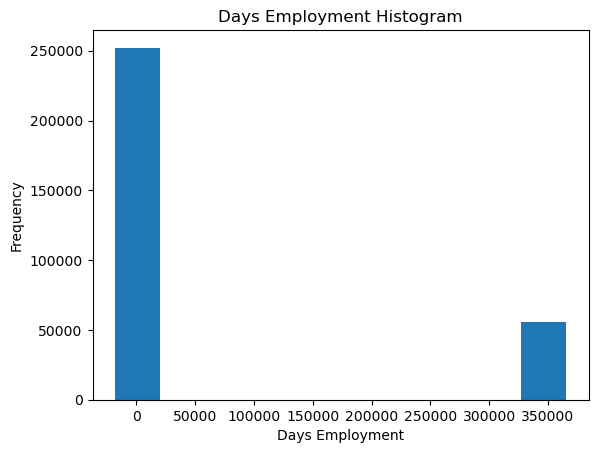

In [155]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [160]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.40% of loans
There are 55374 anomalous days of employment


In [162]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.40% of loans
There are 55374 anomalous days of employment


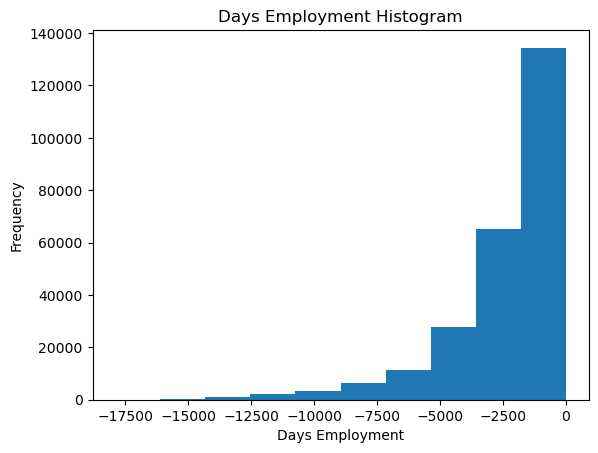

In [164]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [166]:
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)

print('There are %d anomalies in the test data out of %d entries' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

There are 9274 anomalies in the test data out of 48744 entries


C:\Users\nibaj\AppData\Local\Temp\ipykernel_11420\971863607.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)


In [169]:
# Find correlations with the target and sort
correlations = app_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_EMPLOYED                                        0.074958
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

In [170]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

np.float64(-0.07823930830982709)

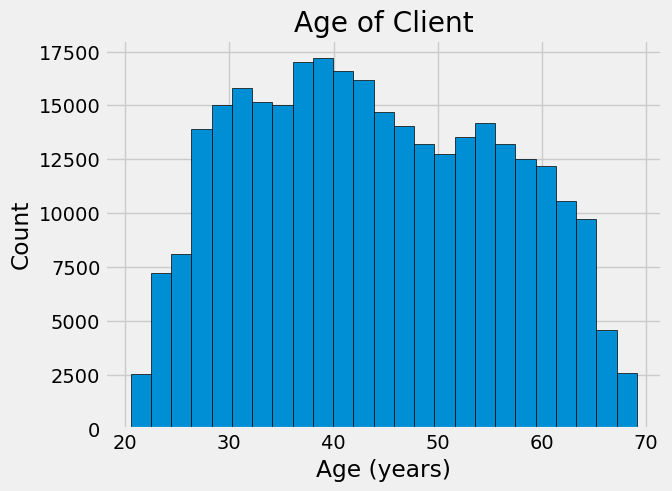

In [171]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count');

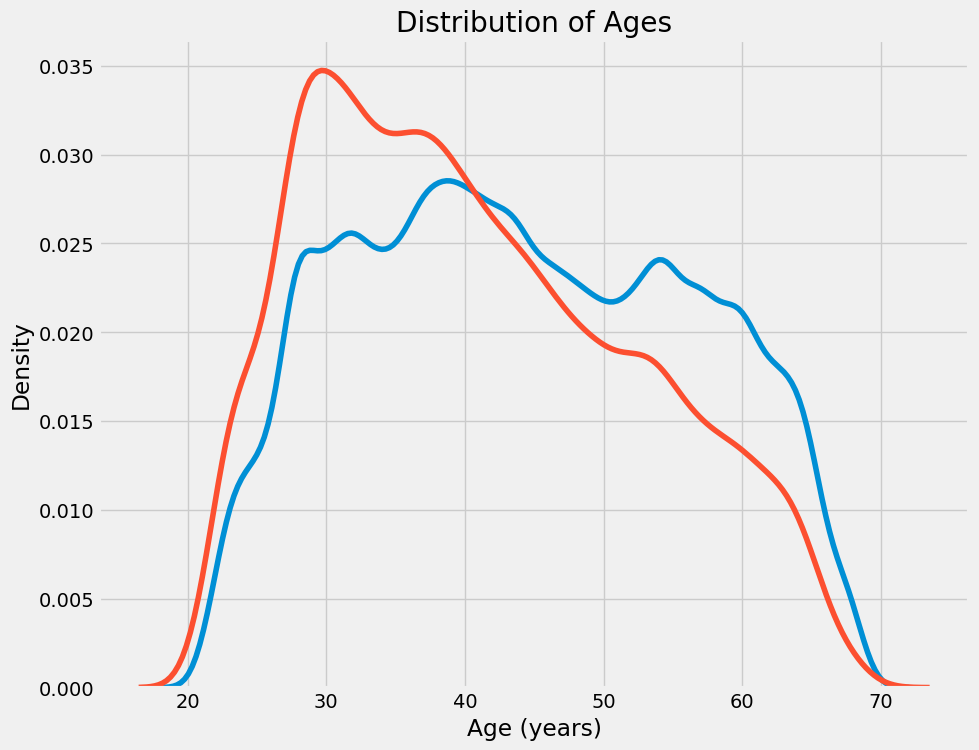

In [172]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1')

# Labeling of plot
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');

In [177]:
# Age information into a separate dataframe
age_data = app_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data.head(10)

C:\Users\nibaj\AppData\Local\Temp\ipykernel_11420\1136001900.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365
C:\Users\nibaj\AppData\Local\Temp\ipykernel_11420\1136001900.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))


,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [179]:
# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

C:\Users\nibaj\AppData\Local\Temp\ipykernel_11420\1757995694.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups  = age_data.groupby('YEARS_BINNED').mean()


,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


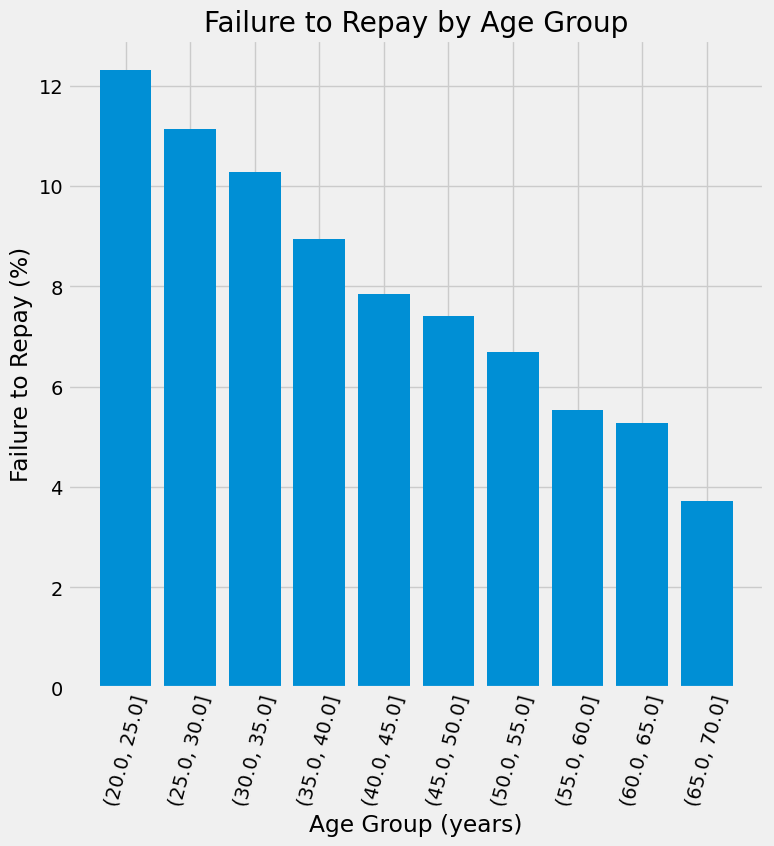

In [181]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group');

In [183]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


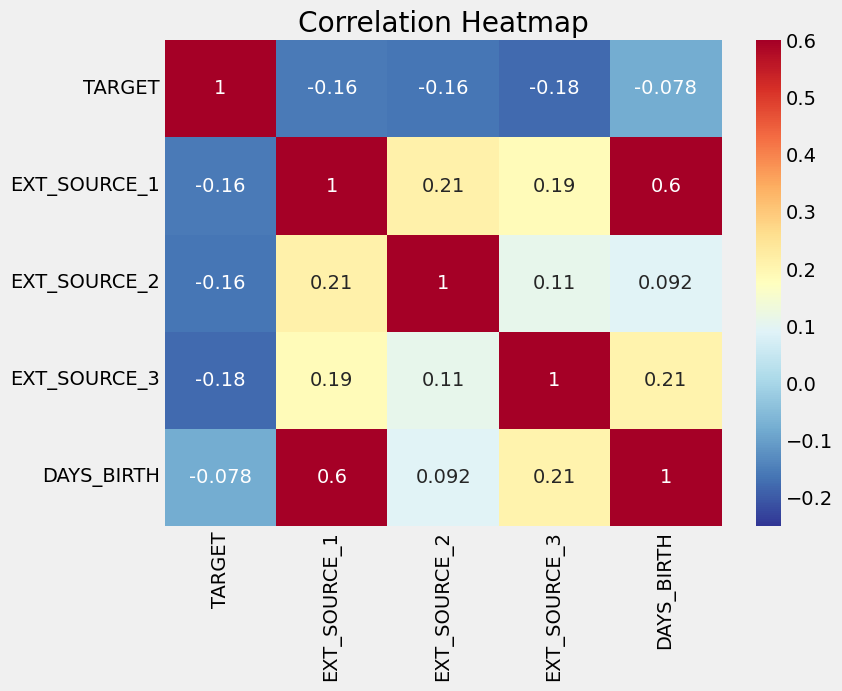

In [185]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap');

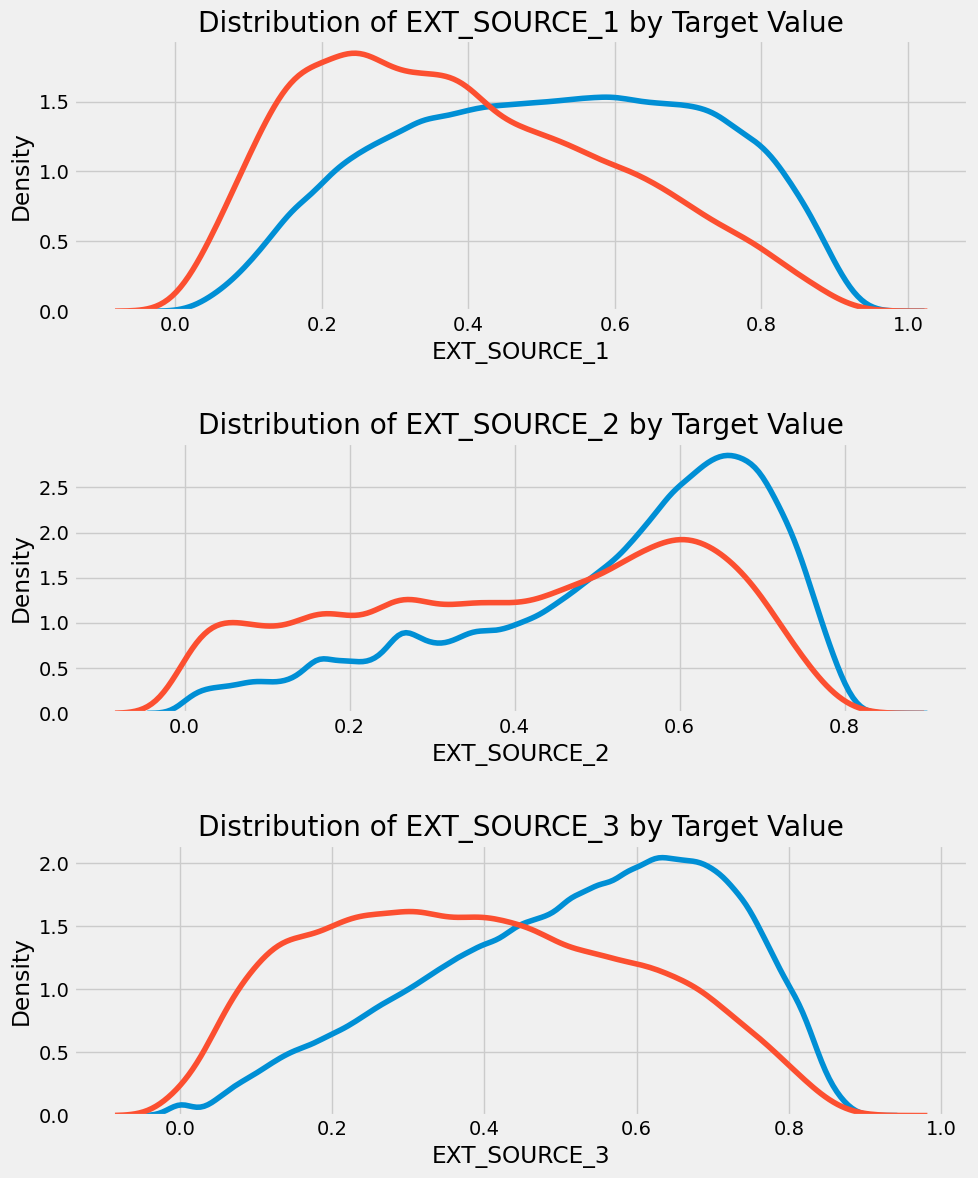

In [187]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

In [201]:
# Copy the data for plotting
plot_data = ext_data.drop(columns = ['DAYS_BIRTH']).copy()

# Add in the age of the client in years
plot_data['YEARS_BIRTH'] = age_data['YEARS_BIRTH']

# Drop na values and limit to first 100000 rows
plot_data = plot_data.dropna().loc[:100000, :]

# Function to calculate correlation coefficient between two columns
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate("r = {:.2f}".format(r),
                xy=(.2, .8), xycoords=ax.transAxes,
                size = 20)

# Create the pairgrid object
grid = sns.PairGrid(data = plot_data, size = 3, diag_sharey=False,
                    hue = 'TARGET', 
                    vars = [x for x in list(plot_data.columns) if x != 'TARGET'])

# Upper is a scatter plot
grid.map_upper(plt.scatter, alpha = 0.2)

# Diagonal is a histogram
grid.map_diag(sns.kdeplot)

# Bottom is density plot
grid.map_lower(sns.kdeplot, cmap = plt.cm.OrRd_r);

plt.suptitle('Ext Source and Age Features Pairs Plot', size = 32, y = 1.05);

TypeError: PairGrid.__init__() got an unexpected keyword argument 'size'

In [193]:
#Make a new dataframe for polynomial features
poly_features = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = app_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# imputer for handling missing values
from sklearn.preprocessing import Imputer
imputer = Imputer(strategy = 'median')

poly_target = poly_features['TARGET']

poly_features = poly_features.drop(columns = ['TARGET'])

# Need to impute missing values
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

ImportError: cannot import name 'Imputer' from 'sklearn.preprocessing' (C:\Users\nibaj\anaconda3\envs\oc_env\lib\site-packages\sklearn\preprocessing\__init__.py)

In [195]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

NameError: name 'poly_transformer' is not defined

In [197]:
poly_features = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = app_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# imputer for handling missing values
from sklearn.preprocessing import Imputer
imputer = Imputer(strategy = 'median')

poly_target = poly_features['TARGET']

poly_features = poly_features.drop(columns = ['TARGET'])

# Need to impute missing values
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

ImportError: cannot import name 'Imputer' from 'sklearn.preprocessing' (C:\Users\nibaj\anaconda3\envs\oc_env\lib\site-packages\sklearn\preprocessing\__init__.py)

In [203]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

NameError: name 'poly_transformer' is not defined

In [205]:
poly_transformer.get_feature_names(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])[:15]

NameError: name 'poly_transformer' is not defined

In [207]:
# Create a dataframe of the features 
poly_features = pd.DataFrame(poly_features, 
                             columns = poly_transformer.get_feature_names(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                           'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Add in the target
poly_features['TARGET'] = poly_target

# Find the correlations with the target
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

NameError: name 'poly_transformer' is not defined

In [209]:
# Put test features into dataframe
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Merge polynomial features into training dataframe
poly_features['SK_ID_CURR'] = app_train['SK_ID_CURR']
app_train_poly = app_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = app_test['SK_ID_CURR']
app_test_poly = app_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Align the dataframes
app_train_poly, app_test_poly = app_train_poly.align(app_test_poly, join = 'inner', axis = 1)

# Print out the new shapes
print('Training data with polynomial features shape: ', app_train_poly.shape)
print('Testing data with polynomial features shape:  ', app_test_poly.shape)

NameError: name 'poly_transformer' is not defined

In [211]:
app_train_domain = app_train.copy()
app_test_domain = app_test.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

In [213]:
app_test_domain['CREDIT_INCOME_PERCENT'] = app_test_domain['AMT_CREDIT'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['ANNUITY_INCOME_PERCENT'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['CREDIT_TERM'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_CREDIT']
app_test_domain['DAYS_EMPLOYED_PERCENT'] = app_test_domain['DAYS_EMPLOYED'] / app_test_domain['DAYS_BIRTH']

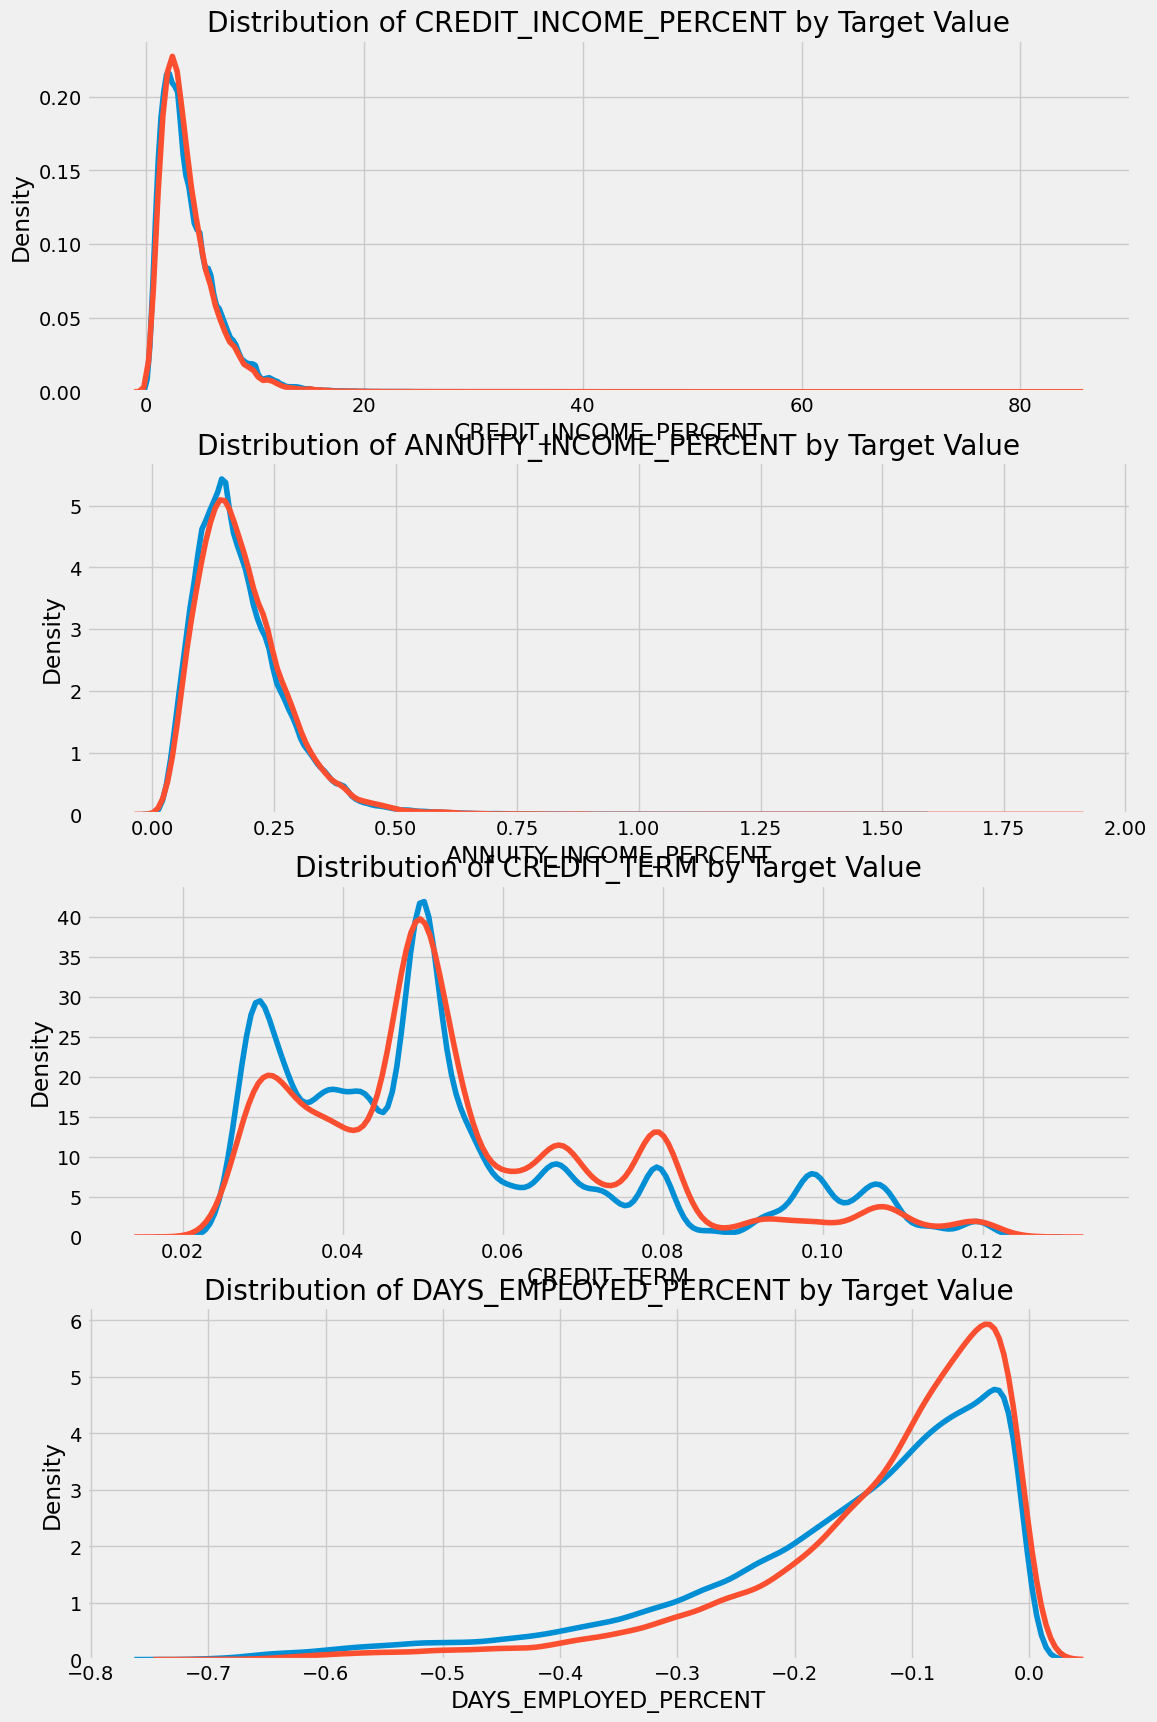

In [215]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    

In [217]:
from sklearn.preprocessing import MinMaxScaler, Imputer

# Drop the target from the training data
if 'TARGET' in app_train:
    train = app_train.drop(columns = ['TARGET'])
else:
    train = app_train.copy()
    
# Feature names
features = list(train.columns)

# Copy of the testing data
test = app_test.copy()

# Median imputation of missing values
imputer = Imputer(strategy = 'median')

# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range = (0, 1))

# Fit on the training data
imputer.fit(train)

# Transform both training and testing data
train = imputer.transform(train)
test = imputer.transform(app_test)

# Repeat with the scaler
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)

ImportError: cannot import name 'Imputer' from 'sklearn.preprocessing' (C:\Users\nibaj\anaconda3\envs\oc_env\lib\site-packages\sklearn\preprocessing\__init__.py)

In [219]:
from sklearn.linear_model import LogisticRegression

# Make the model with the specified regularization parameter
log_reg = LogisticRegression(C = 0.0001)

# Train on the training data
log_reg.fit(train, train_labels)

NameError: name 'train' is not defined

In [221]:
# Make predictions
# Make sure to select the second column only
log_reg_pred = log_reg.predict_proba(test)[:, 1]

NameError: name 'test' is not defined

In [223]:
# Submission dataframe
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = log_reg_pred

submit.head()

NameError: name 'log_reg_pred' is not defined

In [225]:
# Save the submission to a csv file
submit.to_csv('log_reg_baseline.csv', index = False)

In [233]:
app_test = pd.read_csv("application_test.csv")
app_test.head(5)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


Bureau ,pas de doublons 
Beaucoup colonnes avec valeurs Nan
colonnes pertinentes : days credit , credit active , credit type, credit sum

In [100]:
bureau.isna().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
dtype: int64

In [112]:
bureau.duplicated().unique

<bound method Series.unique of 0          False
1          False
2          False
3          False
4          False
           ...  
1716423    False
1716424    False
1716425    False
1716426    False
1716427    False
Length: 1716428, dtype: bool>

In [86]:
bureau_balance = pd.read_csv("bureau_balance.csv")
bureau_balance

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
27299920,5041336,-47,X
27299921,5041336,-48,X
27299922,5041336,-49,X
27299923,5041336,-50,X


In [120]:
credit_card_balance = pd.read_csv("credit_card_balance.csv")
credit_card_balance

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840307,1036507,328243,-9,0.000,45000,NaN,0.0,NaN,NaN,0.000,...,0.000,0.000,NaN,0,NaN,NaN,0.0,Active,0,0
3840308,1714892,347207,-9,0.000,45000,0.0,0.0,0.0,0.0,0.000,...,0.000,0.000,0.0,0,0.0,0.0,23.0,Active,0,0
3840309,1302323,215757,-9,275784.975,585000,270000.0,270000.0,0.0,0.0,2250.000,...,273093.975,273093.975,2.0,2,0.0,0.0,18.0,Active,0,0
3840310,1624872,430337,-10,0.000,450000,NaN,0.0,NaN,NaN,0.000,...,0.000,0.000,NaN,0,NaN,NaN,0.0,Active,0,0
